<h1 style="text-align: center; color: darkblue;">Experiments Dashboard</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Load, Filter & Aggregate Experiments](#4)
5. [Analysis](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

In this notebook, we’ll explore and visualize the results from multiple experiments to identify performance patterns across models and configurations. The goal is to gain insights such as which model families (e.g., decision trees, random forests, neural networks) tend to perform best, and which hyperparameter ranges or combinations lead to consistently strong results. Through comparative plots and summary statistics, we’ll look for trends that can guide future model selection and tuning strategies.


## <a id="2" style="color: darkred; text-decoration: none;"> 2. Setup </a>

In [26]:
import mlflow
import pandas as pd

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

print(mlflow_path)
print(f"sqlite:///{mlflow_path}")

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlflow.db
sqlite:////home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlflow.db


In [28]:
EXPERIMENT_NAME = "network_security"

## <a id="3" style="color: darkred; text-decoration: none;"> 3. Helper Functions </a>

In [29]:
def aggregate_rows(df, param_cols, metric_cols, verbose=True):
    # Safe guard: trim column name whitespace (very common source of bugs)
    df.columns = df.columns.str.strip()
    
    # How many unique parameter combinations and duplicates?
    counts = df.groupby(param_cols, dropna=False).size().reset_index(name='count')

    if verbose:
        print("Unique parameter combos:", counts.shape[0])
        print("Groups with duplicates (>1):")
        print(counts[counts['count'] > 1])
    
    # Aggregate metrics (mean) for each unique param combination
    grouped_metrics = (
        df.groupby(param_cols, dropna=False)[metric_cols]
          .mean()
          .reset_index()
    )
    
    # For the remaining columns, take the first occurrence for each param combo
    other_cols = [c for c in df.columns if c not in param_cols + metric_cols]
    grouped_first = (
        df.groupby(param_cols, dropna=False)[other_cols]
          .first()
          .reset_index()
    )
    
    # Merge back together -> one row per unique parameter combination
    result = pd.merge(grouped_metrics, grouped_first, on=param_cols, how='left')

    
    if verbose:
        print("Original rows:", len(df))
        print("Rows after merging duplicates:", len(result))


    return result


In [30]:
#Visualize performance vs hyperparameters
def plot_f1_vs_hparams(df, model_type, hyperparams, hue=None, size=None):
    """
    Plot F1 vs each hyperparameter for a given model type.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        model_type (str): Filter by model type in 'tags.model_type'.
        hyperparams (list): List of hyperparameter column names.
        hue (str, optional): Column to use for color encoding.
        size (str, optional): Column to use for point size encoding.
    """
    sub = df[df['tags.model_type'] == model_type].copy()
    sub['metrics.f1'] = pd.to_numeric(sub['metrics.f1'], errors='coerce')
    
    n = len(hyperparams)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, hp in enumerate(hyperparams):
        sub[hp] = pd.to_numeric(sub[hp], errors='coerce')
        sns.scatterplot(
            data=sub,
            x=hp,
            y='metrics.f1',
            hue=hue,
            size=size,
            palette='viridis',
            ax=axes[i],
            alpha=0.8
        )
        axes[i].set_title(f"{model_type.upper()} – F1 vs {hp.split('.')[-1]}")
        axes[i].set_xlabel(hp.split('.')[-1])
        axes[i].set_ylabel("F1 Score")

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [31]:
# f1 plot bar
def plot_f1_bar(df, x, hue="tags.model_type", title=None):
    """
    Bar plot of F1 vs categorical hyperparameter, grouped by model type or another hue.
    
    Args:
        df (pd.DataFrame): Results DataFrame.
        x (str): Column name for x-axis (e.g., 'params.val_size', 'params.balance_factor').
        hue (str): Column to use for color grouping (default: 'tags.model_type').
        title (str, optional): Plot title.
    """
    df = df.copy()
    df['metrics.f1'] = pd.to_numeric(df['metrics.f1'], errors='coerce')
    df[x] = df[x].astype(str)  # Treat as categorical for clearer x-axis

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x=x,
        y="metrics.f1",
        hue=hue,
        palette="viridis",
        errorbar="sd"
    )
    plt.title(title or f"F1 Score by {x.split('.')[-1]} and {hue.split('.')[-1]}")
    plt.xlabel(x.split('.')[-1])
    plt.ylabel("F1 Score")
    plt.tight_layout()
    plt.show()


In [32]:
# plot metrics
def plot_model_metrics(df, id_vars=None):
    """
    Visualize performance metrics by model type.

    This function reshapes the given DataFrame from wide to long format,
    detecting all metric columns automatically (those starting with "metrics.").
    It then creates a grouped bar plot showing each model type’s performance
    across different metrics.

    Args:
        df (pd.DataFrame): DataFrame containing experiment results and metrics.
        id_vars (list[str], optional): Columns to keep fixed during the melt operation.
            Defaults to ["tags.model_type", "params.val_size", "params.balance_factor"].

    Returns:
        None: Displays a seaborn bar plot.
    """
    
    df = df.copy()

    # Default grouping columns
    if id_vars is None:
        id_vars = ["tags.model_type", "params.val_size", "params.balance_factor"]

    # Detect all metric columns automatically
    metric_cols = [c for c in df.columns if c.startswith("metrics.")]

    # Melt metrics into long format
    melted = df.melt(
        id_vars=[c for c in id_vars if c in df.columns],
        value_vars=metric_cols,
        var_name="metric",
        value_name="value"
    )

    # Clean metric names
    melted["metric"] = melted["metric"].str.replace("metrics.", "", regex=False)

    # Plot
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=melted,
        x="tags.model_type",
        y="value",
        hue="metric",
        palette="viridis"
    )
    plt.title("Performance Metrics by Model Type")
    plt.xlabel("Model Type")
    plt.ylabel("Metric Value")
    plt.tight_layout()
    plt.show()

## <a id="4" style="color: darkred; text-decoration: none;"> 4. Load, Filter & Aggregate Experiments </a>

In [33]:
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME]) 
df.head(10)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,...,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.git.commit,tags.model_type,tags.dataset,tags.mlflow.source.type,tags.tuning_run_id,tags.data_version,tags.stage,tags.mlflow.user
0,01c3d73038b847a0984fbfc67bf2cd13,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:35.293000+00:00,2026-01-27 20:10:36.034000+00:00,0.997587,0.997587,0.997618,0.997694,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,test_evaluation,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,tree,test,LOCAL,84eb75a670f44d4a8536901bc073e61a,v1,eval,marcos
1,0ca1218e1a2b4df289598d0a39f5d105,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:22.897000+00:00,2026-01-27 20:10:25.447000+00:00,0.981696,0.981696,0.986920,0.993646,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,tree,train/val,LOCAL,None,v1,tune,marcos
2,5180be5cf26746a8980ae6925f39a885,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:14.085000+00:00,2026-01-27 20:10:16.764000+00:00,0.997542,0.997542,0.997567,0.997609,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,tree,train/val,LOCAL,None,v1,tune,marcos
3,df5a82500162405da5f7ab88d598a970,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:00.416000+00:00,2026-01-27 20:10:05.932000+00:00,0.956668,0.956668,0.964094,0.975381,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,nn,train/val,LOCAL,None,v1,tune,marcos
4,4a07d7586c1948d3bd999993c79741a2,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:09:46.743000+00:00,2026-01-27 20:09:53.805000+00:00,0.961969,0.961969,0.965821,0.973332,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,nn,train/val,LOCAL,None,v1,tune,marcos
5,7433b59fdea64fbc82dfa21add7e95cf,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:59:01.353000+00:00,2026-01-27 18:59:04.611000+00:00,0.984606,0.984606,0.989483,0.995584,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Training,08a7b1feffdebb0bd6ae515411728a1c1943e70c,tree,train/val,LOCAL,None,v1,train,marcos
6,011af64ec8f44e96b66d9df197fb76e2,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:58:37.310000+00:00,2026-01-27 18:58:42.338000+00:00,0.947610,0.947610,0.954809,0.967693,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Training,08a7b1feffdebb0bd6ae515411728a1c1943e70c,nn,train/val,LOCAL,None,v1,train,marcos
7,e13fd9017f7b414dbb141329fd261568,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:57:53.911000+00:00,2026-01-27 18:57:54.665000+00:00,0.997587,0.997587,0.997618,0.997694,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,test_evaluation,08a7b1feffdebb0bd6ae515411728a1c1943e70c,tree,test,LOCAL,84eb75a670f44d4a8536901bc073e61a,v1,eval,marcos
8,d8cc003e9da64cae9fa87651d75c4587,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:57:08.791000+00:00,2026-01-27 18:57:13.933000+00:00,0.967337,0.967337,0.970462,0.976778,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,08a7b1feffdebb0bd6ae515411728a1c1943e70c,nn,train/val,LOCAL,None,v1,tune,marcos
9,9d9c77ead4944fac84fd2c6b158a004f,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:54:53.249000+00:00,2026-01-27 18:54:56.560000+00:00,0.997801,0.997801,0.997804,0.997828,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,08a7b1feffdebb0bd6ae515411728a1c1943e70c,tree,train/val,LOCAL,None,v1,tune,marcos


In [34]:
df.shape

(46, 36)

In [35]:
df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.recall', 'metrics.accuracy', 'metrics.f1',
       'metrics.precision', 'params.val_shape', 'params.balance_factor',
       'params.val_size', 'params.max_depth', 'params.criterion',
       'params.train_shape', 'params.min_samples_split', 'params.early_stop',
       'params.optimizer', 'params.batch_size', 'params.scaler_type',
       'params.hidden2', 'params.hidden1', 'params.final_lr', 'params.lr',
       'tags.task', 'tags.mlflow.source.name', 'tags.mlflow.runName',
       'tags.mlflow.source.git.commit', 'tags.model_type', 'tags.dataset',
       'tags.mlflow.source.type', 'tags.tuning_run_id', 'tags.data_version',
       'tags.stage', 'tags.mlflow.user'],
      dtype='object')

In [36]:
aux = df.iloc[2]
aux

run_id                                            5180be5cf26746a8980ae6925f39a885
experiment_id                                                                    1
status                                                                    FINISHED
artifact_uri                     /home/marcos/Escritorio/AI-prod/AI-Driven-Netw...
start_time                                        2026-01-27 20:10:14.085000+00:00
end_time                                          2026-01-27 20:10:16.764000+00:00
metrics.recall                                                            0.997542
metrics.accuracy                                                          0.997542
metrics.f1                                                                0.997567
metrics.precision                                                         0.997609
params.val_shape                                                        (7731, 78)
params.balance_factor                                                          0.2
para

**Filter by Tuning runs**

In [37]:
# Filter by run name and data version
df_tuning = df[
    (df["tags.mlflow.runName"] == "Tuning") &
    (df["tags.data_version"] == "v1")
]

**Filter by good results**

In [38]:
# Let's also filter by metric threshold
df_good = df_tuning[df_tuning["metrics.f1"] > 0.8]

# Inspect
df_good.head(7)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,...,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.git.commit,tags.model_type,tags.dataset,tags.mlflow.source.type,tags.tuning_run_id,tags.data_version,tags.stage,tags.mlflow.user
1,0ca1218e1a2b4df289598d0a39f5d105,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:22.897000+00:00,2026-01-27 20:10:25.447000+00:00,0.981696,0.981696,0.986920,0.993646,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,tree,train/val,LOCAL,None,v1,tune,marcos
2,5180be5cf26746a8980ae6925f39a885,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:14.085000+00:00,2026-01-27 20:10:16.764000+00:00,0.997542,0.997542,0.997567,0.997609,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,tree,train/val,LOCAL,None,v1,tune,marcos
3,df5a82500162405da5f7ab88d598a970,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:10:00.416000+00:00,2026-01-27 20:10:05.932000+00:00,0.956668,0.956668,0.964094,0.975381,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,nn,train/val,LOCAL,None,v1,tune,marcos
4,4a07d7586c1948d3bd999993c79741a2,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 20:09:46.743000+00:00,2026-01-27 20:09:53.805000+00:00,0.961969,0.961969,0.965821,0.973332,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,1a07abbb1274083d2dfcb580a9f118e312a4f0fb,nn,train/val,LOCAL,None,v1,tune,marcos
8,d8cc003e9da64cae9fa87651d75c4587,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:57:08.791000+00:00,2026-01-27 18:57:13.933000+00:00,0.967337,0.967337,0.970462,0.976778,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,08a7b1feffdebb0bd6ae515411728a1c1943e70c,nn,train/val,LOCAL,None,v1,tune,marcos
9,9d9c77ead4944fac84fd2c6b158a004f,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:54:53.249000+00:00,2026-01-27 18:54:56.560000+00:00,0.997801,0.997801,0.997804,0.997828,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,08a7b1feffdebb0bd6ae515411728a1c1943e70c,tree,train/val,LOCAL,None,v1,tune,marcos
10,3e7185c36e3d46458dceb3f1b227f411,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2026-01-27 18:52:10.517000+00:00,2026-01-27 18:52:13.830000+00:00,0.972059,0.972059,0.981083,0.992084,...,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,Tuning,08a7b1feffdebb0bd6ae515411728a1c1943e70c,tree,train/val,LOCAL,None,v1,tune,marcos


**Keep only relevant columns for the analysis**

In [39]:
# keep only relevant columns
columns_to_keep = [
       'start_time',
       'end_time', 
       'metrics.f1', 
       'metrics.recall', 
       'metrics.precision',
       'metrics.accuracy', 
       'params.criterion', 
       'params.max_depth', 
       'params.balance_factor',
       'params.val_size', 
       'params.min_samples_split', 
       'params.scaler_type', 
       'params.optimizer', 
       'params.early_stop',
       'params.hidden1', 
       'params.batch_size', 
       'params.lr', 
       'params.hidden2',
       'params.final_lr', 
       'tags.data_version',
       'tags.model_type']

df_good = df_good[columns_to_keep]

df_good.columns

Index(['start_time', 'end_time', 'metrics.f1', 'metrics.recall',
       'metrics.precision', 'metrics.accuracy', 'params.criterion',
       'params.max_depth', 'params.balance_factor', 'params.val_size',
       'params.min_samples_split', 'params.scaler_type', 'params.optimizer',
       'params.early_stop', 'params.hidden1', 'params.batch_size', 'params.lr',
       'params.hidden2', 'params.final_lr', 'tags.data_version',
       'tags.model_type'],
      dtype='object')

In [40]:
df_good

,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type
1,2026-01-27 20:10:22.897000+00:00,2026-01-27 20:10:25.447000+00:00,0.986920,0.981696,0.993646,0.981696,log_loss,9,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
2,2026-01-27 20:10:14.085000+00:00,2026-01-27 20:10:16.764000+00:00,0.997567,0.997542,0.997609,0.997542,entropy,15,0.2,0.1,...,None,None,None,None,None,None,None,None,v1,tree
3,2026-01-27 20:10:00.416000+00:00,2026-01-27 20:10:05.932000+00:00,0.964094,0.956668,0.975381,0.956668,None,None,0.2,0.1,...,standard,Adam,-1,64,None,0.006914130170243106,128,0.006914130170243106,v1,nn
4,2026-01-27 20:09:46.743000+00:00,2026-01-27 20:09:53.805000+00:00,0.965821,0.961969,0.973332,0.961969,None,None,0.2,0.2,...,standard,Adam,-1,64,None,0.0002516159828053575,128,0.0002516159828053575,v1,nn
8,2026-01-27 18:57:08.791000+00:00,2026-01-27 18:57:13.933000+00:00,0.970462,0.967337,0.976778,0.967337,None,None,0.2,0.2,...,standard,Adam,-1,256,None,0.0012096061535739227,32,0.0012096061535739227,v1,nn
9,2026-01-27 18:54:53.249000+00:00,2026-01-27 18:54:56.560000+00:00,0.997804,0.997801,0.997828,0.997801,gini,17,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
10,2026-01-27 18:52:10.517000+00:00,2026-01-27 18:52:13.830000+00:00,0.981083,0.972059,0.992084,0.972059,entropy,8,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
11,2026-01-27 18:51:22.342000+00:00,2026-01-27 18:51:25.629000+00:00,0.997791,0.997801,0.997796,0.997801,entropy,18,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
12,2026-01-27 18:49:57.643000+00:00,2026-01-27 18:50:00.960000+00:00,0.981440,0.971994,0.993928,0.971994,gini,8,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree
13,2026-01-27 18:49:03.550000+00:00,2026-01-27 18:49:06.832000+00:00,0.997256,0.997219,0.997344,0.997219,gini,14,0.2,0.2,...,None,None,None,None,None,None,None,None,v1,tree


**Aggregation**

Note that we can have different rows with the same configuration. That can happen because we ran the same experiment at different times. Let’s check that:

In [41]:
# check for duplicates
df = df_good


cols = [
    'params.criterion', 'params.max_depth', 'params.balance_factor',
    'params.val_size', 'params.min_samples_split', 'params.scaler_type',
    'params.optimizer', 'params.hidden1', 'params.batch_size',
    'params.lr', 'params.hidden2', 'tags.data_version', 'tags.model_type'
]

# Find duplicate configurations
duplicates = df[df.duplicated(subset=cols, keep=False)].sort_values(by=cols)

duplicates

,start_time,end_time,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy,params.criterion,params.max_depth,params.balance_factor,params.val_size,...,params.scaler_type,params.optimizer,params.early_stop,params.hidden1,params.batch_size,params.lr,params.hidden2,params.final_lr,tags.data_version,tags.model_type


In this case, we have no duplicates.

In general, Running the same model/config multiple times can yield slightly different metrics due to:

- Random initialization (for neural networks).

- Non-deterministic operations.

- Data shuffling or randomness in training.

- Others


Averaging provides a more stable estimate of the expected performance for each configuration. If we had duplicates we will do that.

**Note:** We can also compute the standard deviation to assess variability.



    

In [42]:
metric_cols = ["metrics.recall", "metrics.accuracy", "metrics.f1", "metrics.precision"]

result = aggregate_rows(df, cols, metric_cols, verbose=True)

Unique parameter combos: 33
Groups with duplicates (>1):
Empty DataFrame
Columns: [params.criterion, params.max_depth, params.balance_factor, params.val_size, params.min_samples_split, params.scaler_type, params.optimizer, params.hidden1, params.batch_size, params.lr, params.hidden2, tags.data_version, tags.model_type, count]
Index: []
Original rows: 33
Rows after merging duplicates: 33


In [43]:
result

,params.criterion,params.max_depth,params.balance_factor,params.val_size,params.min_samples_split,params.scaler_type,params.optimizer,params.hidden1,params.batch_size,params.lr,...,tags.data_version,tags.model_type,metrics.recall,metrics.accuracy,metrics.f1,metrics.precision,start_time,end_time,params.early_stop,params.final_lr
0,entropy,12,0.2,0.2,4,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997413,0.997413,0.997433,0.997470,2026-01-26 19:51:53.593000+00:00,2026-01-26 19:51:56.867000+00:00,None,None
1,entropy,12,0.2,0.2,6,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997542,0.997542,0.997560,0.997597,2026-01-26 19:36:18.178000+00:00,2026-01-26 19:36:24.129000+00:00,None,None
2,entropy,13,0.2,0.2,4,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997478,0.997478,0.997480,0.997495,2026-01-27 18:28:04.167000+00:00,2026-01-27 18:28:07.679000+00:00,None,None
3,entropy,15,0.2,0.1,3,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997542,0.997542,0.997567,0.997609,2026-01-27 20:10:14.085000+00:00,2026-01-27 20:10:16.764000+00:00,None,None
4,entropy,17,0.2,0.2,5,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997413,0.997413,0.997410,0.997418,2026-01-27 18:26:41.036000+00:00,2026-01-27 18:26:44.360000+00:00,None,None
5,entropy,18,0.2,0.2,2,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997866,0.997866,0.997861,0.997862,2026-01-27 18:22:08.808000+00:00,2026-01-27 18:22:12.079000+00:00,None,None
6,entropy,18,0.2,0.2,9,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997801,0.997801,0.997791,0.997796,2026-01-27 18:51:22.342000+00:00,2026-01-27 18:51:25.629000+00:00,None,None
7,entropy,19,0.2,0.2,7,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.997478,0.997478,0.997480,0.997487,2026-01-26 23:41:55.142000+00:00,2026-01-26 23:41:58.425000+00:00,None,None
8,entropy,2,0.2,0.2,8,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.870707,0.870707,0.821448,0.779199,2026-01-27 18:20:25.792000+00:00,2026-01-27 18:20:29.214000+00:00,None,None
9,entropy,7,0.2,0.2,3,NaN,NaN,NaN,NaN,NaN,...,v1,tree,0.952138,0.952138,0.969493,0.989965,2026-01-26 18:59:53.337000+00:00,2026-01-26 18:59:57.759000+00:00,None,None


## <a id="5" style="color: darkred; text-decoration: none;"> 5. Analysis </a>

**Strategy:**
    
- Performance metrics by model
    - Gives an overall sense of which model families (Tree, NN, etc.) perform best on average. (broad overview)

- F1 by validation size and model type
    - Shows how model performance scales with different validation splits.

- F1 by balance factor and model type
    - Examines how handling class imbalance affects each model family.

- NN → F1 vs hyperparameters
    - Deep dive into what drives performance for NN models.

- Tree → F1 vs hyperparameters
    - Deep dive into what drives performance for tree models.

- Top-performing runs per model
    - Finish by highlighting the best individual configurations.



**Split by model type**

In [44]:
# split by model type
models = df['tags.model_type'].unique()
for m in models:
    print(f"\n=== {m.upper()} ===")
    display(df[df['tags.model_type'] == m][['metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']].describe())


=== TREE ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,20.000000,20.000000,20.000000,20.000000
mean,0.983529,0.983358,0.984752,0.983358
std,0.039022,0.029497,0.048462,0.029497
min,0.821448,0.870707,0.779199,0.870707
25%,0.985550,0.979287,0.992068,0.979287
50%,0.997422,0.997413,0.997444,0.997413
75%,0.997579,0.997558,0.997616,0.997558
max,0.997861,0.997866,0.997862,0.997866



=== NN ===


,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
count,13.000000,13.000000,13.000000,13.000000
mean,0.963595,0.957322,0.974009,0.957322
std,0.007174,0.009985,0.003334,0.009985
min,0.946741,0.931704,0.966832,0.931704
25%,0.963797,0.956668,0.973332,0.956668
50%,0.964707,0.958864,0.974569,0.958864
75%,0.967758,0.962810,0.975919,0.962810
max,0.973302,0.971024,0.977923,0.971024


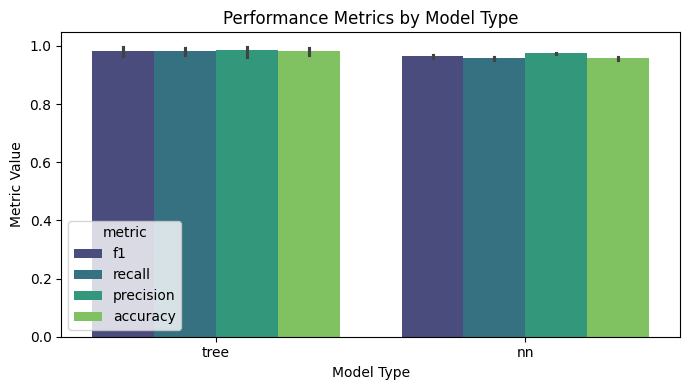

In [45]:
plot_model_metrics(df) # grouping by balance factor and model type

We got slighly better results for the tree.

**F1 by val size and model type**

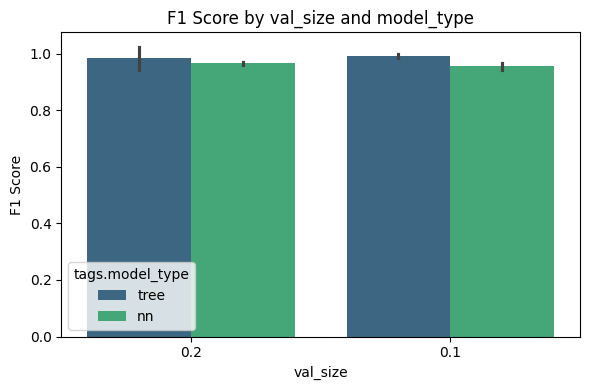

In [46]:
plot_f1_bar(df, x="params.val_size")

For the larger validation size, we got better results on average for the NN, but the best results were obtained with the smaller validation size.


**F1 by balance factor and model type**

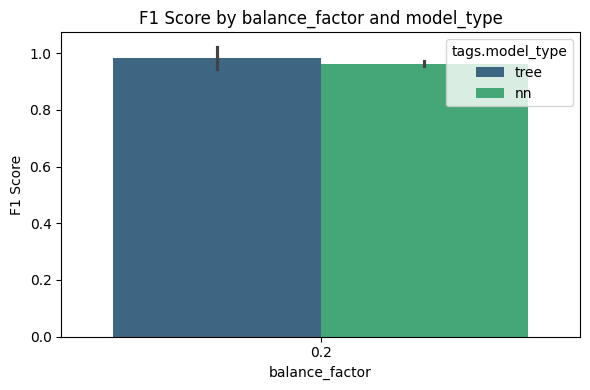

In [47]:
plot_f1_bar(df, x="params.balance_factor", hue="tags.model_type")

We got slightly better results for the tree.

### Hyperparameter space analysis


**Goal**

Identify patterns like:

- For trees: higher max_depth + small min_samples_split yields better recall.

- For NNs: lr between 1e-3 and 1e-4 with batch_size=32 performs best.


**NN -> F1 vs hyperparams**

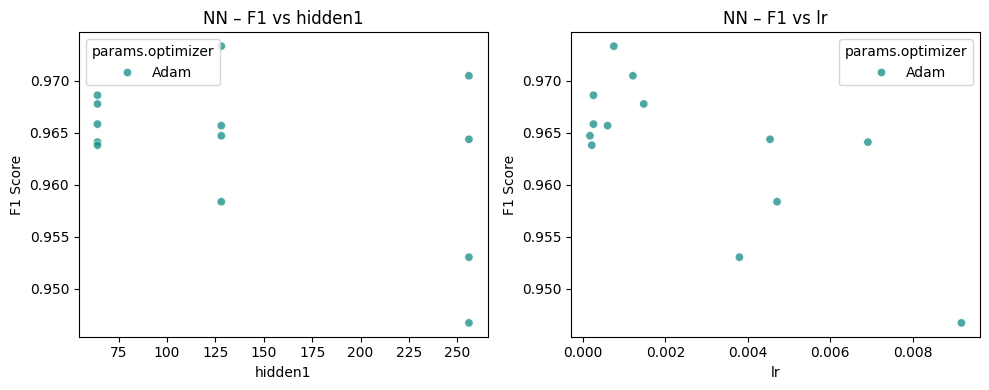

In [54]:
# NN -> f1 vs hyperparams
plot_f1_vs_hparams(
    result,
    model_type='nn',
    hyperparams=['params.hidden1', 'params.lr'],
    hue='params.optimizer',
    #size='params.batch_size'; if I had a batch size
)


We can see that we got better results with smaller learning rates (like 1e-3).”

**Tree -> F1 vs hyperparams**

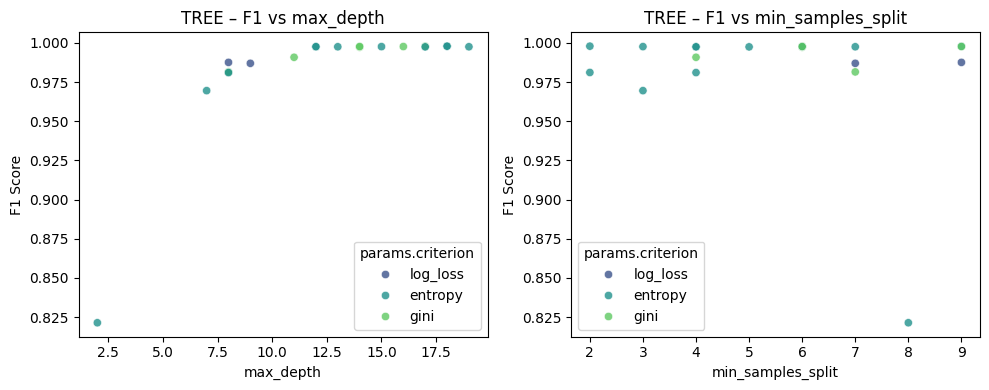

In [55]:
# Tree -> f1 vs hyperparams
plot_f1_vs_hparams(
    df,
    model_type='tree',
    hyperparams=['params.max_depth', 'params.min_samples_split'],
    hue='params.criterion',
)


We can see that we got better results with higher max depths, and entropy or Gini as the criterion.


### Top-performing runs per model

In [56]:
# Identify top-performing runs per model type
top_per_model = (
    df.loc[df.groupby('tags.model_type')['metrics.f1'].idxmax(),
           ['tags.model_type', 'metrics.f1', 'metrics.recall', 'metrics.precision', 'metrics.accuracy']]
)
top_per_model

,tags.model_type,metrics.f1,metrics.recall,metrics.precision,metrics.accuracy
25,nn,0.973302,0.971024,0.977923,0.971024
20,tree,0.997861,0.997866,0.997862,0.997866


Analysis:

- The tree model is clearly superior across all metrics.

- Its recall and precision are both ~0.9978, meaning it catches almost all positives and makes almost no false positives.

- The NN is good (≈0.97) but noticeably worse, especially in recall/accuracy.